# Forecasting the exports volume of processed seafood in Thailand

## 1. Importing Required Libraries
In this cell, we load all the necessary Python libraries used for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`), and machine learning model creation and evaluation (`scikit-learn`).

In [25]:
# Importing standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# Importing machine learning tools
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

## 2. Convert Excel File to CSV 
This script loads an Excel file using the `pandas` library and converts it to a CSV file.

It uses UTF-8 with BOM encoding to ensure compatibility with Excel and excludes the index column from the output.

In [26]:
# Load the .xlsx file (default sheet)
df = pd.read_excel('DATA/Export 2007-2024.xlsx')  # tu peux ajouter sheet_name='NomDeLaFeuille' si nécessaire

# Save as .csv
df.to_csv('DATA/Export 2007-2024.csv', index=False,encoding="utf-8-sig")  # index=False pour ne pas inclure la colonne d’index

## 2. Data Loading, Cleaning, and Feature Engineering
In this section, we prepare the export dataset for modeling. The process includes:
- Loading the CSV file containing monthly seafood export records from 2007 to 2024.
- Creating a datetime column by combining the Year and Month columns, enabling proper chronological sorting and time-based analysis.
- Filtering the dataset by removing rows where all product-related quantities and values are equal to zero, as these records likely represent missing or irrelevant data.
- Sorting the dataset by date to preserve temporal order.
- Generating a numerical time feature called month_num, which represents the number of months elapsed since the beginning of the dataset. This variable is used as the main input for forecasting models.

In [29]:
# Load the CSV file
df = pd.read_csv("DATA/Export 2007-2024.csv")

# Create a datetime column from year and month
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))

# Function to remove rows where all specified columns have a value of 0.0
def supprimer_lignes_tous_zero_colonnes(df, colonnes):
    return df[~df[colonnes].eq(0.0).all(axis=1)]

df = supprimer_lignes_tous_zero_colonnes(df, [
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)',
    'Chilled/Frozen Fresh Shrimp Value (Million Baht)',
    'Dried Shrimp Quantity (Tons)',
    'Dried Shrimp Value (Million Baht)',
    'Boiled or Steamed Shrimp Quantity (Tons)',
    'Boiled or Steamed Shrimp Value (Million Baht)',
    'Shrimp in Airtight Containers Quantity (Tons)',
    'Shrimp in Airtight Containers Value (Million Baht)',
    'Preserved or Processed Shrimp Quantity (Tons)',
    'Preserved or Processed Shrimp Value (Million Baht)',
    'Shrimp Quantity (Tons)',
    'Shrimp Value (Million Baht)',
    'Chilled/Frozen Fresh Squid Quantity (Tons)',
    'Chilled/Frozen Fresh Squid Value (Million Baht)',
    'Dried Squid Quantity (Tons)',
    'Dried Squid Value (Million Baht)',
    'Processed or Preserved Squid Quantity (Tons)',
    'Processed or Preserved Squid Value (Million Baht)',
    'Smoked squid Quantity (Tons)',
    'Smoked squid Value (Million Baht)',
    'Squid Quantity (Tons)',
    'Squid Value (Million Baht)',
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)',
    'Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)',
    'Chilled/Frozen Fish Fillets Quantity (Tons)',
    'Chilled/Frozen Fish Fillets Value (Million Baht)',
    'Dried Fish Quantity (Tons)',
    'Dried Fish Value (Million Baht)',
    'Live Fish and Fish Breeding Stock Quantity (Tons)',
    'Live Fish and Fish Breeding Stock Value (Million Baht)',
    'Fish Quantity (Tons)',
    'Fish Value (Million Baht)',
    'Canned Tuna Quantity (Tons)',
    'Canned Tuna Value (Million Baht)',
    'Canned Sardines Quantity (Tons)',
    'Canned Sardines Value (Million Baht)',
    'Other Canned Fish Quantity (Tons)',
    'Other Canned Fish Value (Million Baht)',
    'Canned Crab Quantity (Tons)',
    'Canned Crab Value (Million Baht)',
    'Other Canned Seafood Quantity (Tons)',
    'Other Canned Seafood Value (Million Baht)',
    'Canned Products Quantity (Tons)',
    'Canned Products Value (Million Baht)',
    'Canned Dog and Cat Food Quantity (Tons)',
    'Canned Dog and Cat Food Value (Million Baht)',
    'Processed Seafood Products Quantity (Tons)',
    'Processed Seafood Products Value (Million Baht)',
    'Processed Tuna Products Quantity (Tons)',
    'Processed Tuna Products Value (Million Baht)',
    'Preserved or Processed Crab Quantity (Tons)',
    'Preserved or Processed Crab Value (Million Baht)',
    'Other Processed Seafood Products Quantity (Tons)',
    'Other Processed Seafood Products Value (Million Baht)',
    'Other Fishery Products Quantity (Tons)',
    'Other Fishery Products Value (Million Baht)',
    'Grand Total Quantity (Tons)',
    'Grand Total Value (Million Baht)'])

# Sort the dataset by month
df = df.sort_values('month')

# Create a numerical time feature (number of months since start)
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')

## 3. Classification Models

### 3.1 Model Selection

We are testing several machine learning models:

* Logistic Regression
* SVM (Support Vector Machine)
* Decision Trees
* Random Forest
* K-Nearest Neighbors (KNN)

We will apply the same training method to the different models we are going to test and compare their performance.

### 3.2 Splitting the Dataset for Cross-Validation

We use 5-fold cross-validation with stratified sampling to evaluate model performance more reliably:
* The dataset is split into 5 distinct subsets of equal size.
* For each iteration, 80% of the data is used for training and the remaining 20% is used for testing, without overlap between test sets.
* This ensures that every data point is used exactly once for testing, allowing a more robust and generalized evaluation of the model.
* Stratified splitting ensures that each fold preserves the original class distribution, which is particularly important for imbalanced datasets.

In [22]:
# Cross-validation setup
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### 3.3 Model Evaluation Methodology

In this section, we implement a comparative analysis of several machine learning models to forecast Thailand’s monthly seafood export volume. The methodology consists of the following steps:

- **Data Preparation**:
We use cleaned and time-encoded data including a numerical time index and cyclical features (month sine and cosine) to capture seasonality.

- **Validation Strategy**:
A TimeSeriesSplit with 5 folds is used to respect the chronological order of the data during training and evaluation.

- **Performance Metrics**:
For each model and fold, we compute:

    - Root Mean Squared Error (RMSE)

    - R² Score (Coefficient of Determination)
Average and standard deviation values are calculated to assess both accuracy and consistency

- **Visualization**:

    - For the last fold of each model, a scatter plot is generated comparing actual vs. predicted values.

    - A final forecasting plot displays each model’s predicted export volume from the start of the dataset up to 2030, along with the actual historical data for comparison.

This approach allows us to identify which model best captures the trends and seasonal behavior in export quantities, while also testing their generalization capability beyond the observed data.

### 3.4 Applying the Models


=== Linear Regression ===

--- Fold 1 ---
RMSE: 13961.7851
R²: 0.0430

--- Fold 2 ---
RMSE: 21492.5861
R²: -3.2249

--- Fold 3 ---
RMSE: 14139.9536
R²: -0.4877

--- Fold 4 ---
RMSE: 14063.6371
R²: -0.8916

--- Fold 5 ---
RMSE: 19991.3981
R²: -1.2974


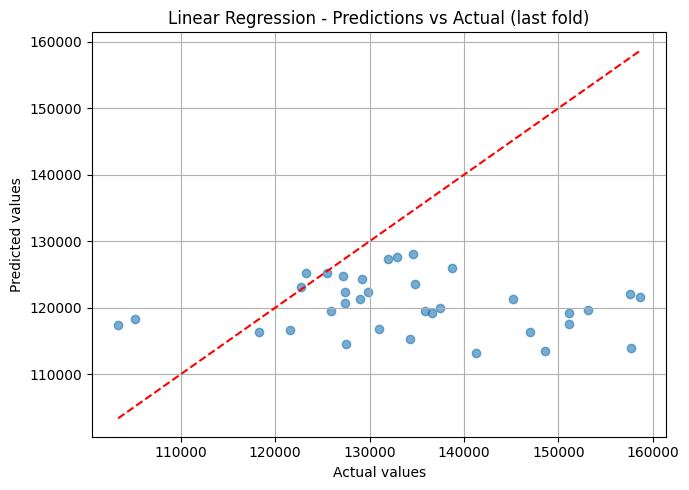


=== SVR ===

--- Fold 1 ---
RMSE: 14754.6254
R²: -0.0687

--- Fold 2 ---
RMSE: 21046.1845
R²: -3.0512

--- Fold 3 ---
RMSE: 28340.8471
R²: -4.9767

--- Fold 4 ---
RMSE: 20275.5112
R²: -2.9318

--- Fold 5 ---
RMSE: 16660.2716
R²: -0.5956


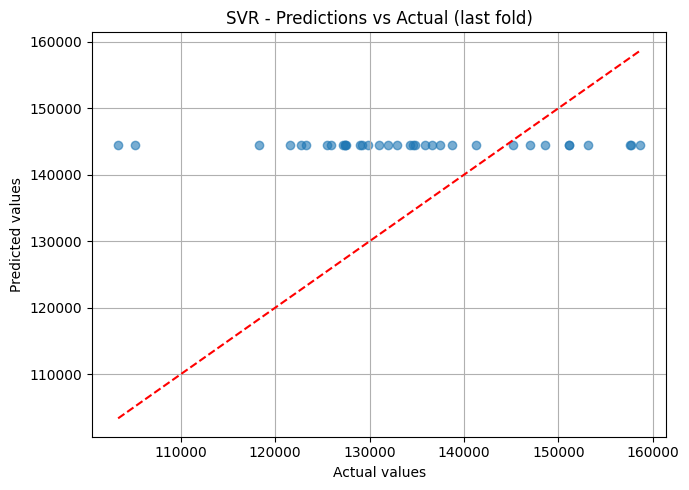


=== Decision Tree ===

--- Fold 1 ---
RMSE: 13157.3056
R²: 0.1501

--- Fold 2 ---
RMSE: 26085.3913
R²: -5.2235

--- Fold 3 ---
RMSE: 13636.5714
R²: -0.3837

--- Fold 4 ---
RMSE: 11038.2821
R²: -0.1653

--- Fold 5 ---
RMSE: 14294.9379
R²: -0.1747


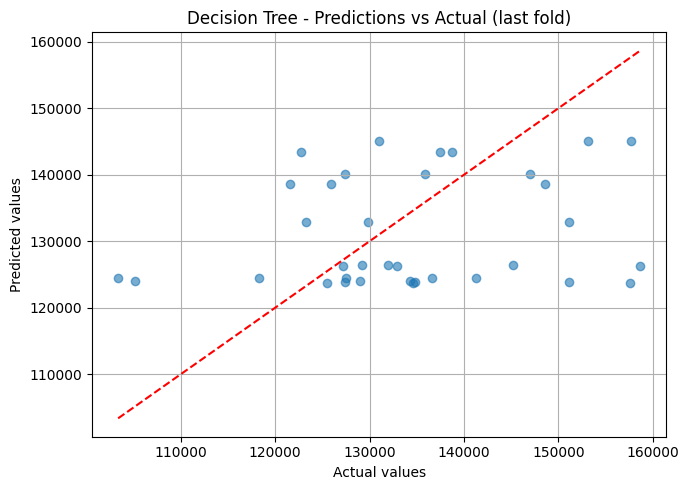


=== Random Forest ===

--- Fold 1 ---
RMSE: 12196.0714
R²: 0.2698

--- Fold 2 ---
RMSE: 18719.3601
R²: -2.2049

--- Fold 3 ---
RMSE: 11743.6145
R²: -0.0262

--- Fold 4 ---
RMSE: 11047.5942
R²: -0.1673

--- Fold 5 ---
RMSE: 12451.6732
R²: 0.1087


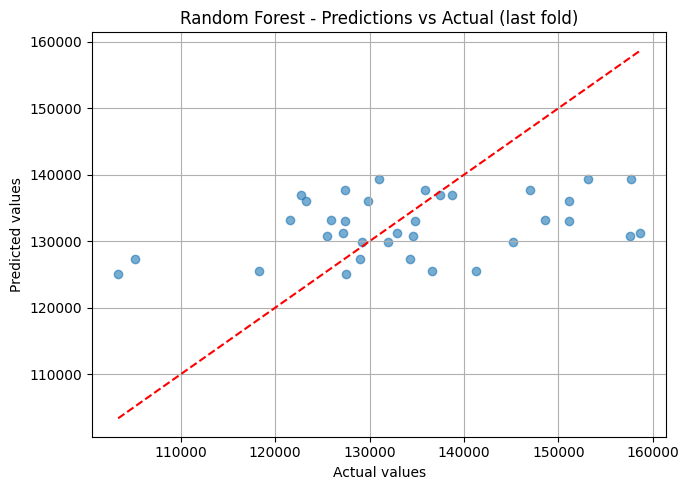


=== KNN ===

--- Fold 1 ---
RMSE: 14292.2445
R²: -0.0028

--- Fold 2 ---
RMSE: 15791.6621
R²: -1.2808

--- Fold 3 ---
RMSE: 13956.2199
R²: -0.4493

--- Fold 4 ---
RMSE: 11065.9176
R²: -0.1712

--- Fold 5 ---
RMSE: 13313.3142
R²: -0.0189


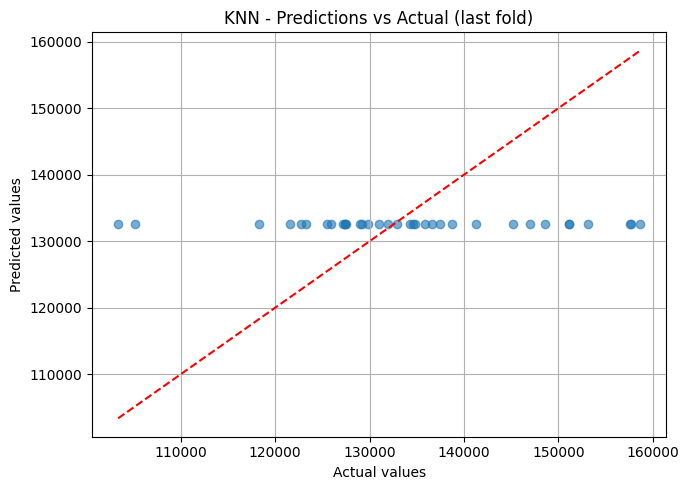


=== Summary of Results ===
                    RMSE mean   RMSE std  R² mean  R² std
Linear Regression  16729.8720  3310.5827  -1.1717  1.1183
SVR                20215.4880  4672.8087  -2.3248  1.7893
Decision Tree      15642.4976  5334.2041  -1.1594  2.0392
Random Forest      13231.6627  2784.9631  -0.4040  0.9120
KNN                13683.8717  1541.3026  -0.3846  0.4759


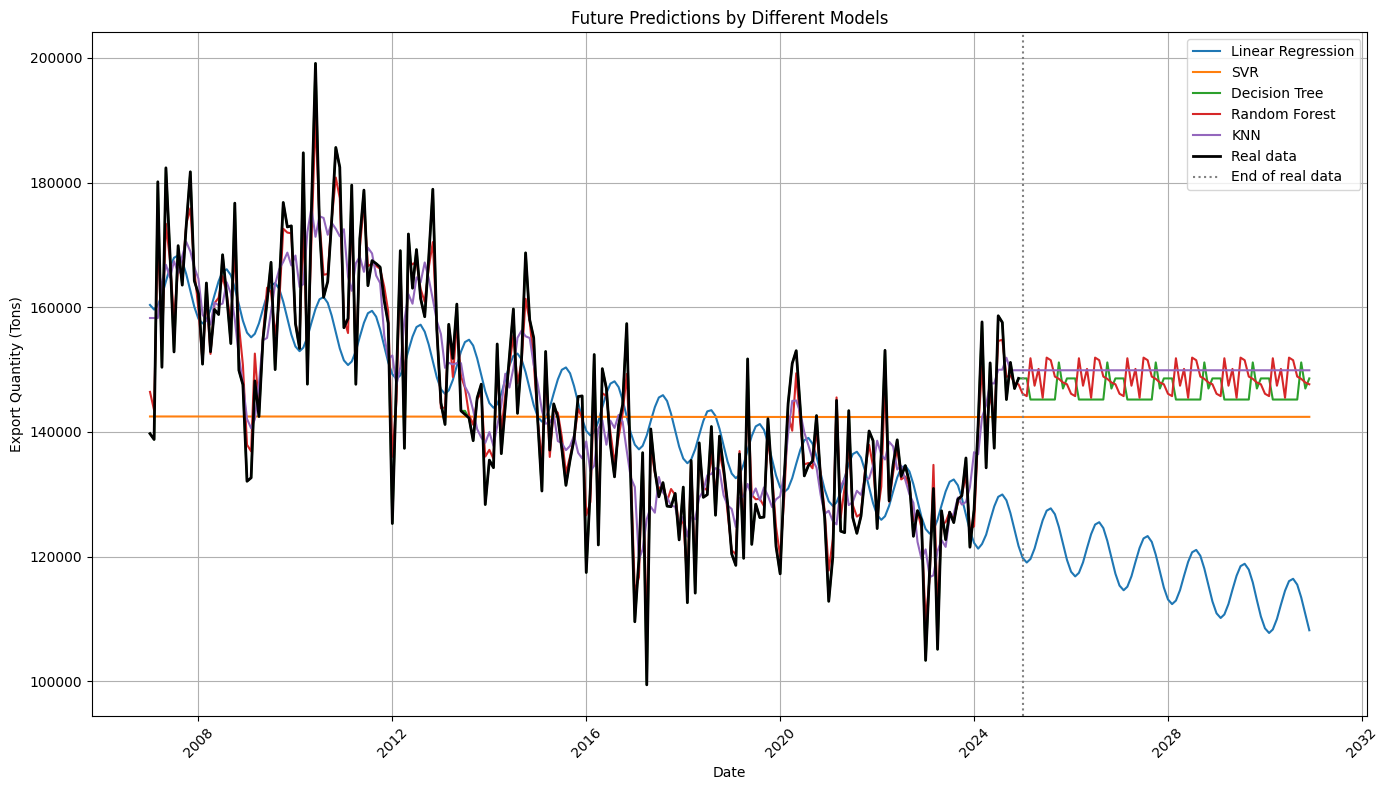

In [ ]:
# --- Data loading and preprocessing ---

df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month

# Cyclical variables to handle seasonality
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# --- Models to evaluate ---

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        # Plot predictions vs actual values for the last fold
        if i == tscv.get_n_splits() - 1:  
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# --- Summary of results ---

summary_df = pd.DataFrame(results).T.round(4)

print("\n=== Summary of Results ===")
print(summary_df)

# --- Future prediction using all available data ---

all_months = pd.date_range(start=df['month'].min(), end="2030-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos
})


plt.figure(figsize=(14, 8))

# Retrain model on the entire dataset
for name, model in models.items():
    
    model.fit(X, y)
    y_all_pred = model.predict(X_all)
    
    plt.plot(all_months, y_all_pred, label=name)

plt.plot(df['month'], y, label="Real data", color='black', linewidth=2)
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='End of real data')
plt.xlabel("Date")
plt.ylabel("Export Quantity (Tons)")
plt.title("Future Predictions by Different Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning 
In this section, we re-evaluate the five machine learning models using hyperparameter optimization to improve their performance.

### 4.1  Grid Search Hyperparameter Tuning for Regression Models

The goal is to determine the best combination of hyperparameters for each model using grid search combined with time series cross-validation `(TimeSeriesSplit)`, which ensures that the temporal order of the data is respected during training and validation.

**Key elements of this process:**
- A hyperparameter grid is defined for each model (except Linear Regression, which has no tunable hyperparameters).

- For each model, GridSearchCV tests all combinations of hyperparameters using 5-fold time series CV and evaluates them based on negative mean squared error.

- The best-performing model configuration (lowest RMSE) is saved for each algorithm.

- A summary table is printed showing:

    - The best hyperparameter set (Best Params)

    - The corresponding cross-validated RMSE (Best CV RMSE)

This tuning step aims to maximize the predictive accuracy of each model before proceeding to final evaluations and future forecasting.

In [33]:
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter search spaces for each model
param_grids = {
    "Linear Regression": {},  # No hyperparameters to tune here
    
    "SVR": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.01, 0.1, 0.5]
    },
    
    "Decision Tree": {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    
    "KNN": {
        'n_neighbors': [3, 5, 7, 10],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
    }
}

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

best_models = {}
results = {}

for name, model in models.items():
    print(f"\n=== Hyperparameter tuning for {name} ===")
    
    param_grid = param_grids.get(name, {})
    
    # If there are no hyperparameters, skip the search
    if not param_grid:
        print("No hyperparameters to tune for this model.")
        model.fit(X, y)
        best_models[name] = model
        continue
    
    grid_search = GridSearchCV(
        model, 
        param_grid, 
        cv=tscv, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1, 
        verbose=1
    )
    
    grid_search.fit(X, y)
    
    best_models[name] = grid_search.best_estimator_
    
    best_rmse = (-grid_search.best_score_) ** 0.5
    
    print(f"Best params for {name}: {grid_search.best_params_}")
    print(f"Best CV RMSE: {best_rmse:.4f}")
    
    results[name] = {
        "Best Params": grid_search.best_params_,
        "Best CV RMSE": best_rmse
    }

# Summary display
import pandas as pd
summary_df = pd.DataFrame(results).T
print("\n=== Summary of Hyperparameter Tuning Results ===")
print(summary_df)


=== Hyperparameter tuning for Linear Regression ===
No hyperparameters to tune for this model.

=== Hyperparameter tuning for SVR ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params for SVR: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
Best CV RMSE: 20590.6514

=== Hyperparameter tuning for Decision Tree ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV RMSE: 13921.7242

=== Hyperparameter tuning for Random Forest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE: 13357.0428

=== Hyperparameter tuning for KNN ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for KNN: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Best CV RMSE: 13054.7777

=== Summary of Hyperparameter 

### 4.2  Evaluation of Optimized Models and Long-Term Forecasting

In this section, we re-evaluate all five machine learning models using their best hyperparameter configurations, obtained previously through grid search. Each model is validated using a 5-fold time series cross-validation to compute its predictive accuracy and stability.

**Methodology**:
- We use the same input features (month_num, month_sin, month_cos) and target (Grand Total Quantity (Tons)).

- For each model:

    - The model is trained and evaluated across 5 consecutive folds.

    - Performance metrics include: RMSE (Root Mean Squared Error) and R² Score (Coefficient of Determination)

    - A scatter plot is generated for the final fold, comparing actual vs. predicted values.

- A summary table of average performance is printed for model comparison.

- Finally, all models are re-trained on the full dataset and used to forecast seafood export volumes up to *December 2030*.

The results are visualized in a single plot showing each model's predicted trend alongside the historical data.

This step highlights how the tuned models perform under realistic, temporally ordered validation, and assesses their ability to extrapolate future export trends.


=== Random Forest ===

--- Fold 1 ---
RMSE: 11646.4101
R²: 0.3341

--- Fold 2 ---
RMSE: 18427.9422
R²: -2.1059

--- Fold 3 ---
RMSE: 11594.5680
R²: -0.0003

--- Fold 4 ---
RMSE: 10805.4623
R²: -0.1167

--- Fold 5 ---
RMSE: 12452.3613
R²: 0.1086


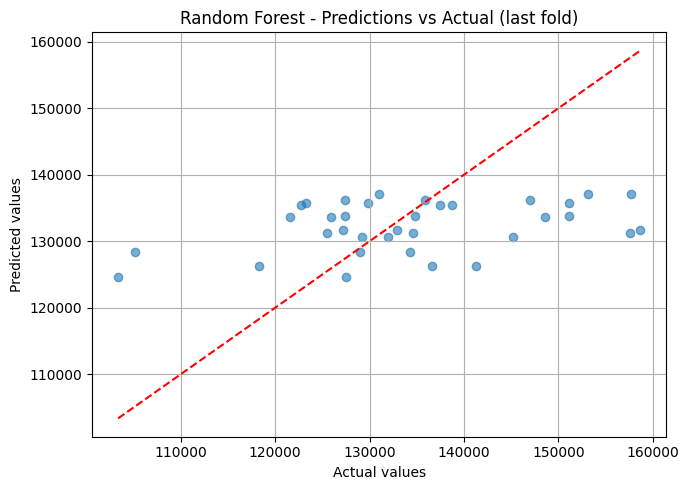


=== Summary of Results ===
                RMSE mean   RMSE std  R² mean  R² std
Random Forest  12985.3488  2770.7339   -0.356  0.8875


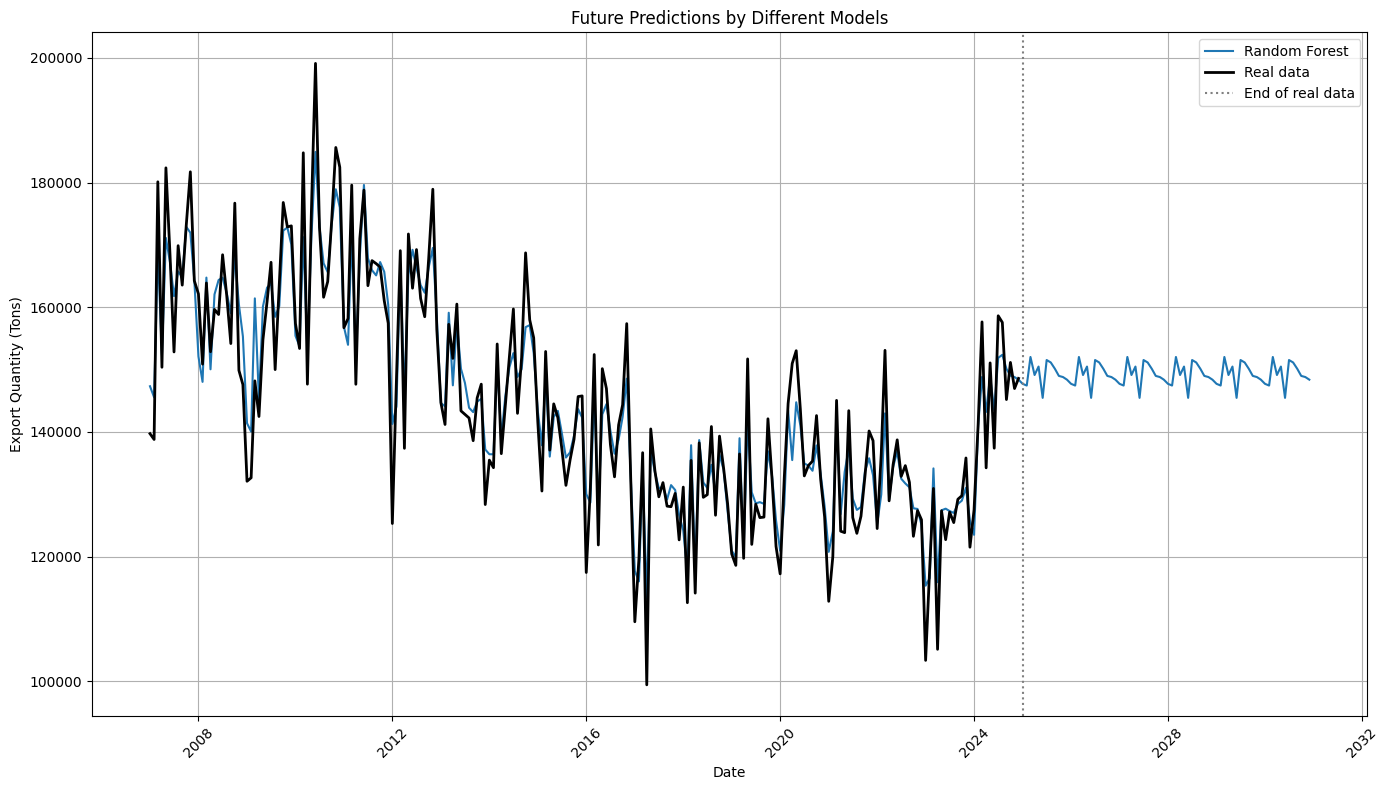

In [ ]:
# --- Data Loading and Preparation ---

df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month

# Cyclical variables to capture seasonality
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# --- Models to Evaluate ---

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(C= 10, epsilon= 0.01, gamma= 'scale'),
    "Decision Tree": DecisionTreeRegressor(max_depth= 10, min_samples_leaf= 4, min_samples_split= 10),
    "Random Forest": RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200),
    "KNN": KNeighborsRegressor(n_neighbors= 3, p= 1, weights= 'uniform')
}

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        # Plot last fold predictions
        if i == tscv.get_n_splits() - 1:  
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# --- Summary of Results ---

summary_df = pd.DataFrame(results).T.round(4)

print("\n=== Summary of Results ===")
print(summary_df)

# --- Future Prediction on the Complete Timeline ---

all_months = pd.date_range(start=df['month'].min(), end="2030-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos
})

plt.figure(figsize=(14, 8))

# Retrain model on the full dataset
for name, model in models.items():

    model.fit(X, y)
    y_all_pred = model.predict(X_all)
    
    plt.plot(all_months, y_all_pred, label=name)

plt.plot(df['month'], y, label="Real data", color='black', linewidth=2)
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='End of real data')
plt.xlabel("Date")
plt.ylabel("Export Quantity (Tons)")
plt.title("Future Predictions by Different Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

RMSE CV: Moyenne = 12927.90, Écart-type = 2684.03


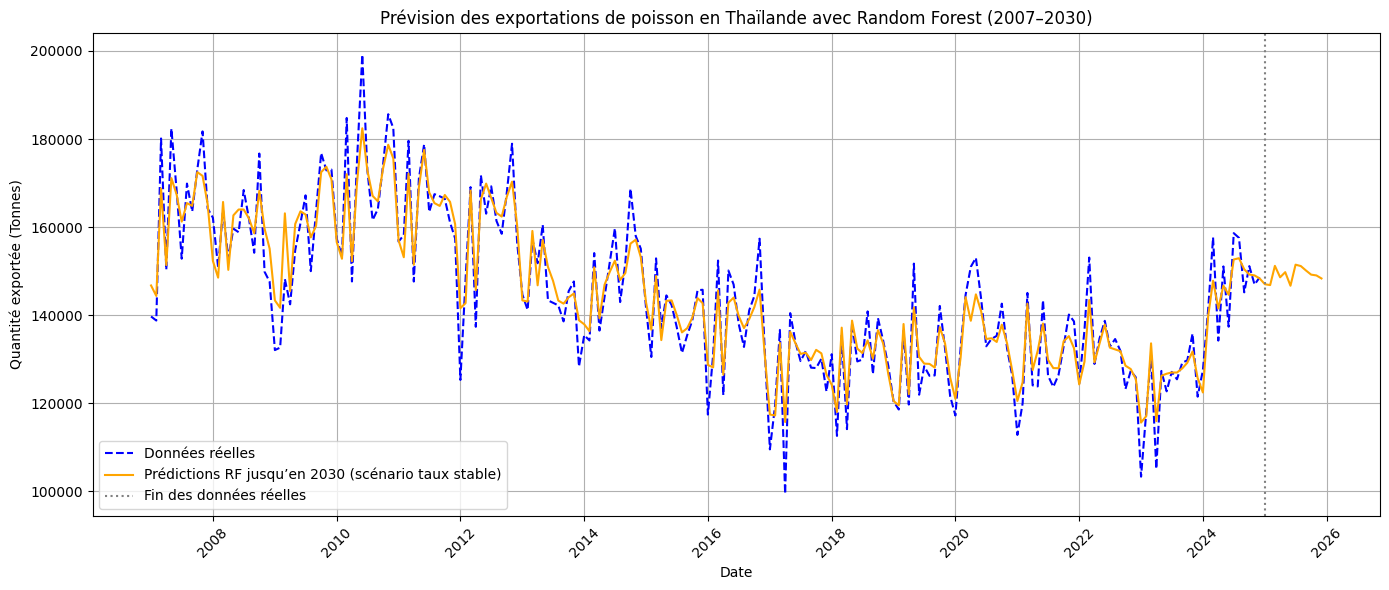

In [18]:
import pandas as pd

summary_df = pd.DataFrame(results).T.round(4)

# Préparer la colonne de dates
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')

# Ajouter des variables temporelles
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

# Features + cible
X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# Modèle
model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200)

# Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

# Entraînement complet sur 2007–2024
model.fit(X, y)

# ---------- SCÉNARIO SIMPLE POUR 2025–2030 ----------
# Créer tous les mois de la période complète
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

# Étendre 'Price baht to usd' :
# - pour les mois connus : utiliser les vraies valeurs
# - pour 2025–2030 : utiliser une valeur constante (moyenne)
last_real_month = df['month'].max()
price_projection_start = last_real_month + pd.DateOffset(months=1)



# Créer DataFrame de prédiction complet
X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
})

# Prédiction
y_all_pred = model.predict(X_all)

# ---------- AFFICHAGE ----------
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles", linestyle="--", color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions RF jusqu’en 2030 (scénario taux stable)", color='orange')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande avec Random Forest (2007–2030)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


RMSE CV: Moyenne = 12121.77, Écart-type = 2055.21


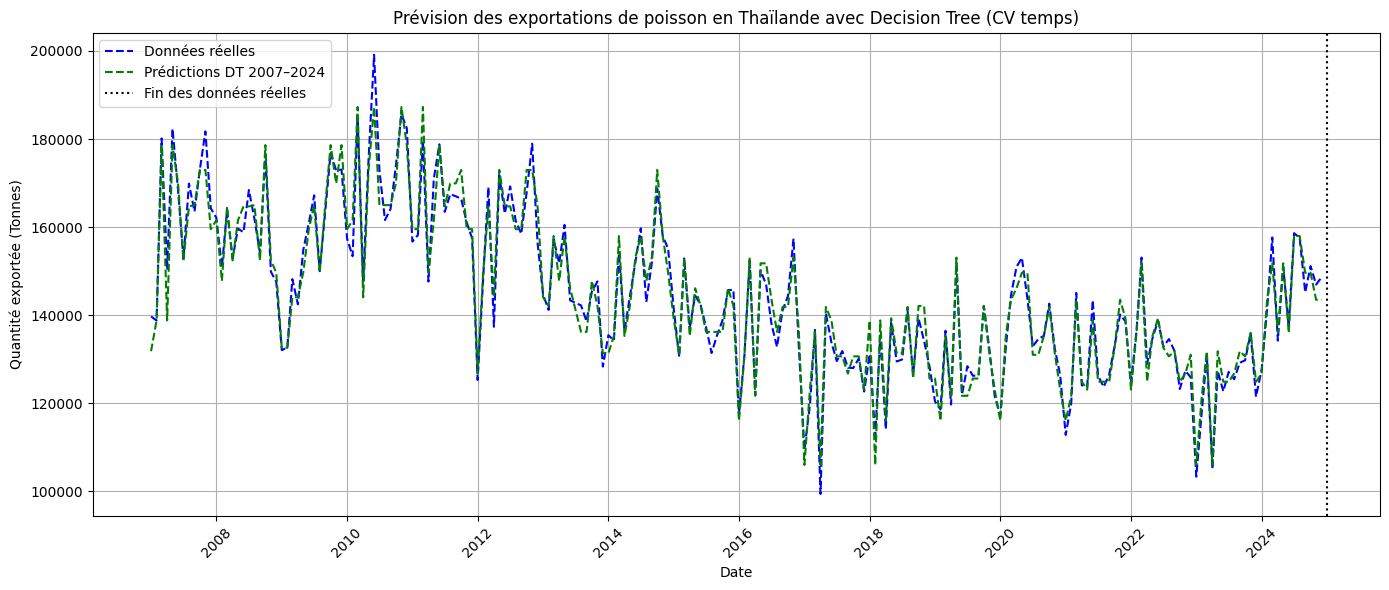

In [19]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt



# Définir features et cible
#X=df[['month_num', 'month_sin', 'month_cos']]
X = df[['month_num', 'month_sin', 'month_cos', 'Grand Total Value (Million Baht)',
        'Chilled/Frozen Fresh Shrimp Quantity (Tons)', 'Chilled/Frozen Fresh Shrimp Value (Million Baht)',
        'Dried Shrimp Quantity (Tons)','Dried Shrimp Value (Million Baht)',
        'Boiled or Steamed Shrimp Quantity (Tons)','Boiled or Steamed Shrimp Value (Million Baht)',
        'Shrimp in Airtight Containers Quantity (Tons)','Shrimp in Airtight Containers Value (Million Baht)',
        'Preserved or Processed Shrimp Quantity (Tons)','Preserved or Processed Shrimp Value (Million Baht)',
        'Shrimp Quantity (Tons)','Shrimp Value (Million Baht)',
        'Chilled/Frozen Fresh Squid Quantity (Tons)', 'Chilled/Frozen Fresh Squid Value (Million Baht)',
        'Dried Squid Quantity (Tons)', 'Dried Squid Value (Million Baht)',
        'Processed or Preserved Squid Quantity (Tons)', 'Processed or Preserved Squid Value (Million Baht)',
        'Smoked squid Quantity (Tons)', 'Smoked squid Value (Million Baht)',
        'Squid Quantity (Tons)','Squid Value (Million Baht)',
        'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)', 'Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)',
        'Chilled/Frozen Fish Fillets Quantity (Tons)', 'Chilled/Frozen Fish Fillets Value (Million Baht)',
        'Dried Fish Quantity (Tons)', 'Dried Fish Value (Million Baht)',
        'Live Fish and Fish Breeding Stock Quantity (Tons)', 'Live Fish and Fish Breeding Stock Value (Million Baht)',
        'Fish Quantity (Tons)','Fish Value (Million Baht)',
        'Canned Tuna Quantity (Tons)', 'Canned Tuna Value (Million Baht)',
        'Canned Sardines Quantity (Tons)', 'Canned Sardines Value (Million Baht)',
        'Other Canned Fish Quantity (Tons)', 'Other Canned Fish Value (Million Baht)',
        'Canned Crab Quantity (Tons)', 'Canned Crab Value (Million Baht)',
        'Other Canned Seafood Quantity (Tons)', 'Other Canned Seafood Value (Million Baht)',
        'Canned Products Quantity (Tons)','Canned Products Value (Million Baht)',
        'Canned Dog and Cat Food Quantity (Tons)', 'Canned Dog and Cat Food Value (Million Baht)',
        'Processed Seafood Products Quantity (Tons)', 'Processed Seafood Products Value (Million Baht)',
        'Processed Tuna Products Quantity (Tons)', 'Processed Tuna Products Value (Million Baht)',
        'Preserved or Processed Crab Quantity (Tons)', 'Preserved or Processed Crab Value (Million Baht)',
        'Other Processed Seafood Products Quantity (Tons)', 'Other Processed Seafood Products Value (Million Baht)',
        'Other Fishery Products Quantity (Tons)', 'Other Fishery Products Value (Million Baht)'
        ]]
y = df['Grand Total Quantity (Tons)'].values

# Initialiser le modèle DecisionTree
model = DecisionTreeRegressor(max_depth= 10, min_samples_leaf= 4, min_samples_split= 10)

# Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

# Entraîner sur toutes les données
model.fit(X, y)

# Générer les mois jusqu'à 2030
all_months = pd.date_range(start=df['month'].min(), end="2024-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]


X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
    'Grand Total Value (Million Baht)' : df['Grand Total Value (Million Baht)'],
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)': df['Chilled/Frozen Fresh Shrimp Quantity (Tons)'], 
    'Chilled/Frozen Fresh Shrimp Value (Million Baht)': df['Chilled/Frozen Fresh Shrimp Value (Million Baht)'],
    'Dried Shrimp Quantity (Tons)': df['Dried Shrimp Quantity (Tons)'], 
    'Dried Shrimp Value (Million Baht)': df['Dried Shrimp Value (Million Baht)'],
    'Boiled or Steamed Shrimp Quantity (Tons)': df['Boiled or Steamed Shrimp Quantity (Tons)'], 
    'Boiled or Steamed Shrimp Value (Million Baht)': df['Boiled or Steamed Shrimp Value (Million Baht)'],
    'Shrimp in Airtight Containers Quantity (Tons)': df['Shrimp in Airtight Containers Quantity (Tons)'],
    'Shrimp in Airtight Containers Value (Million Baht)': df['Shrimp in Airtight Containers Value (Million Baht)'],
    'Preserved or Processed Shrimp Quantity (Tons)': df['Preserved or Processed Shrimp Quantity (Tons)'],
    'Preserved or Processed Shrimp Value (Million Baht)': df['Preserved or Processed Shrimp Value (Million Baht)'],
    'Shrimp Quantity (Tons)' : df['Shrimp Quantity (Tons)'],
    'Shrimp Value (Million Baht)' : df['Shrimp Value (Million Baht)'],
    'Chilled/Frozen Fresh Squid Quantity (Tons)': df['Chilled/Frozen Fresh Squid Quantity (Tons)'],
    'Chilled/Frozen Fresh Squid Value (Million Baht)' : df['Chilled/Frozen Fresh Squid Value (Million Baht)'],
    'Dried Squid Quantity (Tons)': df['Dried Squid Quantity (Tons)'],
    'Dried Squid Value (Million Baht)' : df['Dried Squid Value (Million Baht)'],
    'Processed or Preserved Squid Quantity (Tons)': df['Processed or Preserved Squid Quantity (Tons)'],
    'Processed or Preserved Squid Value (Million Baht)' : df['Processed or Preserved Squid Value (Million Baht)'],
    'Smoked squid Quantity (Tons)':df['Smoked squid Quantity (Tons)'],
    'Smoked squid Value (Million Baht)' :df ['Smoked squid Value (Million Baht)'],
    'Squid Quantity (Tons)': df['Squid Quantity (Tons)'],
    'Squid Value (Million Baht)': df['Squid Value (Million Baht)'],
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)': df['Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)'],
    'Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)' : df['Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)'],
    'Chilled/Frozen Fish Fillets Quantity (Tons)': df['Chilled/Frozen Fish Fillets Quantity (Tons)'],
    'Chilled/Frozen Fish Fillets Value (Million Baht)': df['Chilled/Frozen Fish Fillets Value (Million Baht)'],
    'Dried Fish Quantity (Tons)': df['Dried Fish Quantity (Tons)'],
    'Dried Fish Value (Million Baht)': df['Dried Fish Value (Million Baht)'],
    'Live Fish and Fish Breeding Stock Quantity (Tons)': df['Live Fish and Fish Breeding Stock Quantity (Tons)'],
    'Live Fish and Fish Breeding Stock Value (Million Baht)': df['Live Fish and Fish Breeding Stock Value (Million Baht)'],
    'Fish Quantity (Tons)' :df['Fish Quantity (Tons)'],
    'Fish Value (Million Baht)' : df['Fish Value (Million Baht)'],
    'Canned Tuna Quantity (Tons)': df['Canned Tuna Quantity (Tons)'],
    'Canned Tuna Value (Million Baht)': df['Canned Tuna Value (Million Baht)'],
    'Canned Sardines Quantity (Tons)': df['Canned Sardines Quantity (Tons)'],
    'Canned Sardines Value (Million Baht)' : df['Canned Sardines Value (Million Baht)'],
    'Other Canned Fish Quantity (Tons)': df['Other Canned Fish Quantity (Tons)'],
    'Other Canned Fish Value (Million Baht)': df['Other Canned Fish Value (Million Baht)'],
    'Canned Crab Quantity (Tons)': df['Canned Crab Quantity (Tons)'],
    'Canned Crab Value (Million Baht)': df['Canned Crab Value (Million Baht)'],
    'Other Canned Seafood Quantity (Tons)': df['Other Canned Seafood Quantity (Tons)'],
    'Other Canned Seafood Value (Million Baht)': df['Other Canned Seafood Value (Million Baht)'],
    'Canned Products Quantity (Tons)' : df['Canned Products Quantity (Tons)'],
    'Canned Products Value (Million Baht)' : df['Canned Products Value (Million Baht)'],
    'Canned Dog and Cat Food Quantity (Tons)': df['Canned Dog and Cat Food Quantity (Tons)'],
    'Canned Dog and Cat Food Value (Million Baht)': df['Canned Dog and Cat Food Value (Million Baht)'],
    'Processed Seafood Products Quantity (Tons)': df['Processed Seafood Products Quantity (Tons)'],
    'Processed Seafood Products Value (Million Baht)': df['Processed Seafood Products Value (Million Baht)'],
    'Processed Tuna Products Quantity (Tons)': df['Processed Tuna Products Quantity (Tons)'],
    'Processed Tuna Products Value (Million Baht)': df['Processed Tuna Products Value (Million Baht)'],
    'Preserved or Processed Crab Quantity (Tons)': df['Preserved or Processed Crab Quantity (Tons)'],
    'Preserved or Processed Crab Value (Million Baht)': df['Preserved or Processed Crab Value (Million Baht)'],
    'Other Processed Seafood Products Quantity (Tons)' : df['Other Processed Seafood Products Quantity (Tons)'],
    'Other Processed Seafood Products Value (Million Baht)' : df['Other Processed Seafood Products Value (Million Baht)'],
    'Other Fishery Products Quantity (Tons)' : df['Other Fishery Products Quantity (Tons)'],
    'Other Fishery Products Value (Million Baht)' : df['Other Fishery Products Value (Million Baht)']
})

# Prédictions
y_all_pred = model.predict(X_all)

# Affichage
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles",  linestyle="--",color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions DT 2007–2024", linestyle="--", color='green')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='black', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande avec Decision Tree (CV temps)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
